# Native spacing distribution vs planned target spacing

Uses nnU-Net's `dataset_fingerprint.json` (computed from the raw source images across all 1296 cases) to check how much real native-resolution detail is discarded by resampling to the planned target spacing `[1.0, 0.8984, 0.8594]` mm.

See `IDEAS.md` → "High-Resolution Training for Small Lesion Detection" for how this feeds into the high-res training decision.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

FINGERPRINT_PATH = "../nnunet_preprocessed/Dataset001_BraTSMETS/dataset_fingerprint.json"
TARGET_SPACING = np.array([1.0, 0.8984000086784363, 0.8593999743461609])  # planned target (x, y, z)
AXIS_NAMES = ['x', 'y', 'z']

d = json.load(open(FINGERPRINT_PATH))
spacings = np.array(d["spacings"])
n = len(spacings)
print(f"{n} cases, target spacing (x,y,z): {TARGET_SPACING}")

1296 cases, target spacing (x,y,z): [1.         0.89840001 0.85939997]


## Per-axis spacing statistics

In [2]:
for i, name in enumerate(AXIS_NAMES):
    col = spacings[:, i]
    print(f"{name}: min={col.min():.4f}  median={np.median(col):.4f}  mean={col.mean():.4f}  max={col.max():.4f}")

non_iso = ~np.all(np.isclose(spacings, 1.0, atol=1e-3), axis=1)
print(f"\ncases with native spacing != (1,1,1): {non_iso.sum()}/{n} ({non_iso.sum()/n:.1%})")

x: min=0.4297  median=1.0000  mean=1.0417  max=5.0000
y: min=0.3594  median=0.8984  mean=0.8086  max=2.0000
z: min=0.3594  median=0.8594  mean=0.8053  max=1.2000

cases with native spacing != (1,1,1): 931/1296 (71.8%)


## Distribution per axis

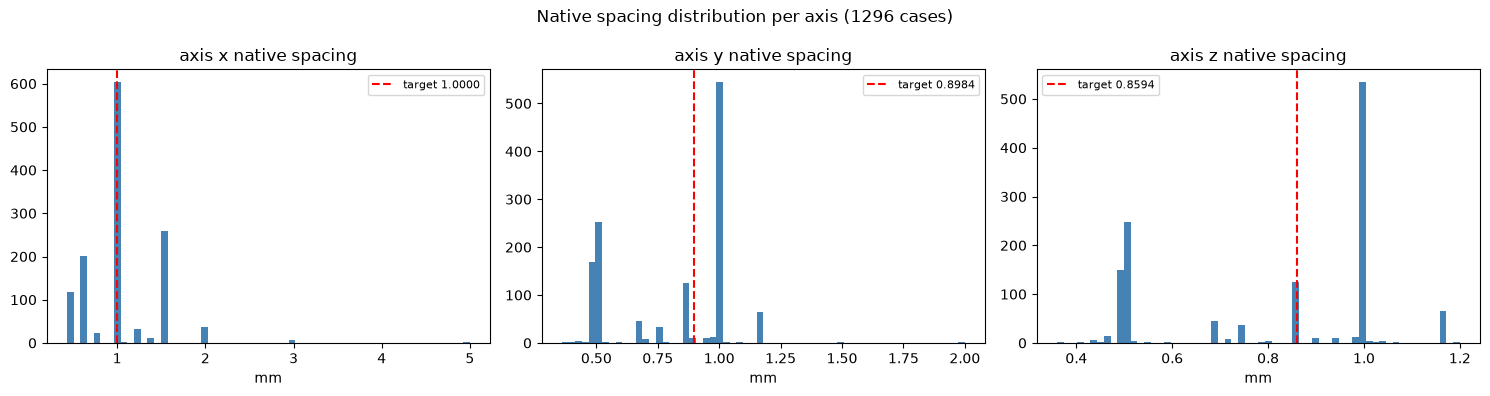

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, name in enumerate(AXIS_NAMES):
    axes[i].hist(spacings[:, i], bins=60, color='steelblue')
    axes[i].axvline(TARGET_SPACING[i], color='red', linestyle='--', label=f'target {TARGET_SPACING[i]:.4f}')
    axes[i].set_title(f'axis {name} native spacing')
    axes[i].set_xlabel('mm')
    axes[i].legend(fontsize=8)
fig.suptitle('Native spacing distribution per axis (1296 cases)')
fig.tight_layout()
fig.savefig('spacing_per_axis_hist.png', dpi=130, bbox_inches='tight')
plt.show()

## How many cases have native spacing significantly (>20%) finer than the planned target?

"Finer" = smaller spacing value = more detail. Native spacing below `target * 0.8` on an axis means real resolution is being discarded by resampling on that axis.

In [4]:
threshold = TARGET_SPACING * 0.8
finer_per_axis = spacings < threshold  # (n, 3) bool

for i, name in enumerate(AXIS_NAMES):
    c = finer_per_axis[:, i].sum()
    print(f"axis {name}: {c}/{n} cases ({c/n:.1%}) finer than {threshold[i]:.4f} (target {TARGET_SPACING[i]:.4f})")

any_axis = finer_per_axis.any(axis=1)
all_axes = finer_per_axis.all(axis=1)
print(f"\nany axis >20% finer than planned: {any_axis.sum()}/{n} ({any_axis.sum()/n:.1%})")
print(f"all three axes >20% finer than planned: {all_axes.sum()}/{n} ({all_axes.sum()/n:.1%})")

axis x: 323/1296 cases (24.9%) finer than 0.8000 (target 1.0000)
axis y: 486/1296 cases (37.5%) finer than 0.7187 (target 0.8984)
axis z: 477/1296 cases (36.8%) finer than 0.6875 (target 0.8594)

any axis >20% finer than planned: 633/1296 (48.8%)
all three axes >20% finer than planned: 169/1296 (13.0%)


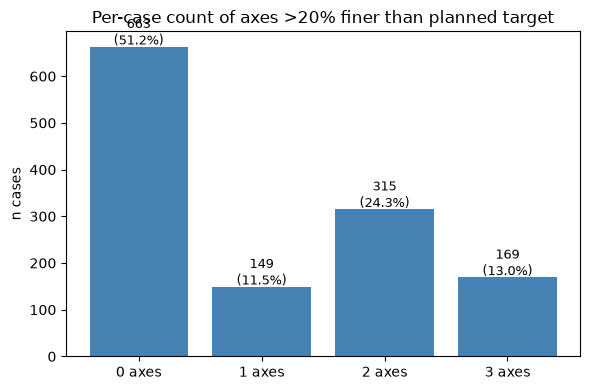

In [5]:
n_finer_axes = finer_per_axis.sum(axis=1)
counts = [(n_finer_axes == k).sum() for k in range(4)]
labels = [f'{k} axes' for k in range(4)]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, counts, color='steelblue')
ax.set_ylabel('n cases')
ax.set_title('Per-case count of axes >20% finer than planned target')
for b, c in zip(bars, counts):
    ax.text(b.get_x() + b.get_width()/2, c + 5, f'{c}\n({c/n:.1%})', ha='center', fontsize=9)
fig.tight_layout()
fig.savefig('spacing_finer_axis_counts.png', dpi=130, bbox_inches='tight')
plt.show()

## Summary

- Roughly half the dataset (48.8%) has native resolution >20% finer than the planned resampling target on at least one axis — real detail is discarded for these cases, not just interpolated.
- 13.0% are finer on all three axes (genuinely high-res acquisitions, not just thin-slice artifacts on one axis).
- This is a bigger fraction of the dataset than the "sub-mm is a small minority" framing in the original high-res-training idea implied — see `IDEAS.md` update (2026-07-10).